<a href="https://colab.research.google.com/github/Saurav-K-yadav/ml_learning/blob/main/Pytorch/pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


1. DATA (Preparing and loading)

In [40]:
weight=0.7
bias=0.3

In [41]:
X=torch.arange(0,1,00.02)
X=X.unsqueeze(dim=1)
Y=weight*X+bias
# X.shape
X[:10],Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [42]:
len(X),len(Y)

(50, 50)

splitting data into training and testing

In [43]:
trainSplit=int(0.8*len(X))
X_train,Y_train=X[:trainSplit],Y[:trainSplit]
X_test,Y_test=X[trainSplit:],Y[trainSplit:]

In [60]:
from matplotlib.typing import FillStyleType
def plot_predictions(train_data,train_labels,test_data,test_labels,predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")
  plt.scatter(test_data,test_labels,c="r",s=4,label="Test data")

  plt.legend()
  if predictions is not None:
      plt.scatter(test_data,predictions,c="yellow",s=4,label="Prediction data",marker='^')



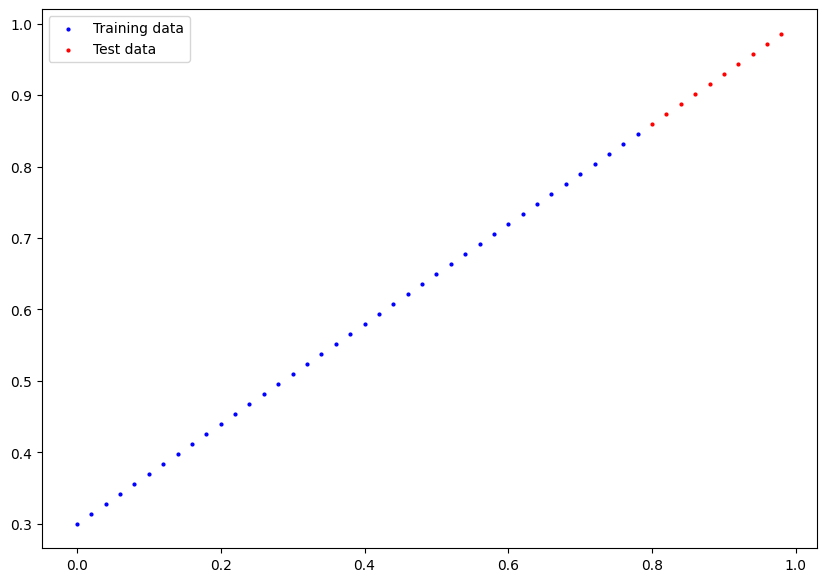

In [45]:
plot_predictions(X_train,Y_train,X_test,Y_test)

Building pytorch model

In [46]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.rand(1,requires_grad=True))
    self.bias=nn.Parameter(torch.rand(1,requires_grad=True))
  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bias


In [47]:
torch.manual_seed(42)
modelZero=LinearRegression()
list(modelZero.parameters())


[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [48]:
with torch.inference_mode():
  y_pred=modelZero(X_test)
y_pred


tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [49]:
#setting up loss function
lossfn=nn.L1Loss()

# setup  an optimizer
optimizer=torch.optim.SGD(params=modelZero.parameters())


In [53]:
epochs=1000
for epoch in range(epochs):
  modelZero.train()
  optimizer.zero_grad()
  y_pred=modelZero(X_train)
  loss=lossfn(y_pred,Y_train)
  print(loss)
  loss.backward()
  optimizer.step()
  modelZero.eval()
  with torch.inference_mode():
    test_pred=modelZero(X_test)
    test_loss=lossfn(test_pred,Y_test)
    print(f"Epoch:{epoch} Loss:{loss}")



tensor(0.4557, grad_fn=<MeanBackward0>)
Epoch:0 Loss:0.45567208528518677
tensor(0.4545, grad_fn=<MeanBackward0>)
Epoch:1 Loss:0.45451998710632324
tensor(0.4534, grad_fn=<MeanBackward0>)
Epoch:2 Loss:0.4533678889274597
tensor(0.4522, grad_fn=<MeanBackward0>)
Epoch:3 Loss:0.4522158205509186
tensor(0.4511, grad_fn=<MeanBackward0>)
Epoch:4 Loss:0.45106372237205505
tensor(0.4499, grad_fn=<MeanBackward0>)
Epoch:5 Loss:0.4499116539955139
tensor(0.4488, grad_fn=<MeanBackward0>)
Epoch:6 Loss:0.4487595558166504
tensor(0.4476, grad_fn=<MeanBackward0>)
Epoch:7 Loss:0.44760745763778687
tensor(0.4465, grad_fn=<MeanBackward0>)
Epoch:8 Loss:0.4464553892612457
tensor(0.4453, grad_fn=<MeanBackward0>)
Epoch:9 Loss:0.445303350687027
tensor(0.4442, grad_fn=<MeanBackward0>)
Epoch:10 Loss:0.44415122270584106
tensor(0.4430, grad_fn=<MeanBackward0>)
Epoch:11 Loss:0.44299912452697754
tensor(0.4418, grad_fn=<MeanBackward0>)
Epoch:12 Loss:0.441847026348114
tensor(0.4407, grad_fn=<MeanBackward0>)
Epoch:13 Loss:0.4

In [54]:
with torch.inference_mode():
  y_preds_new=modelZero(X_test)

In [58]:
y_preds_new.

tensor([[0.8595],
        [0.8735],
        [0.8875],
        [0.9015],
        [0.9154],
        [0.9294],
        [0.9434],
        [0.9574],
        [0.9714],
        [0.9854]])

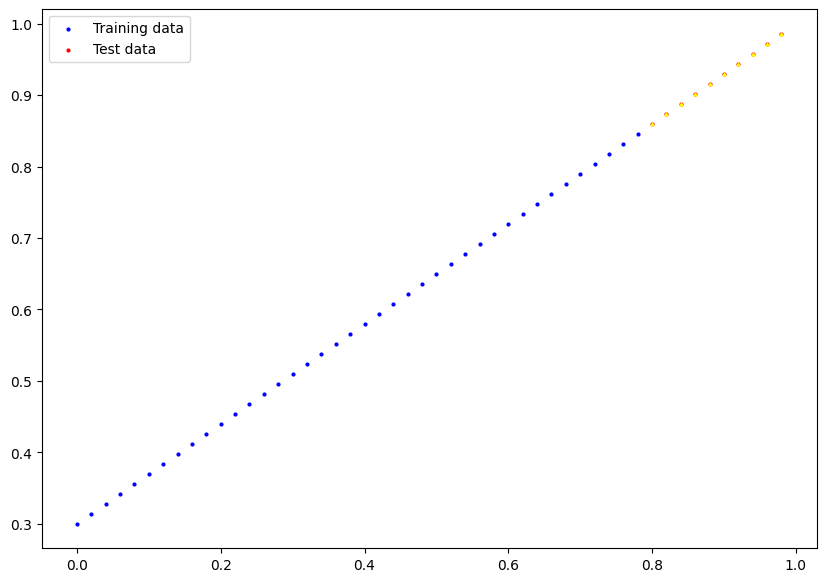

In [61]:
plot_predictions(X_train,Y_train,X_test,Y_test,predictions=y_preds_new)

In [ ]:
# saving a model in pytorch
# torch.save(modelZero.state_dict(),/)

# to load model
# torch.load()
